In [1]:
#  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  display options
pd.set_option('display.max_columns', None)

#  dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [2]:
# Check for missing values
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
# Check percentage of missing values
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

<Axes: >

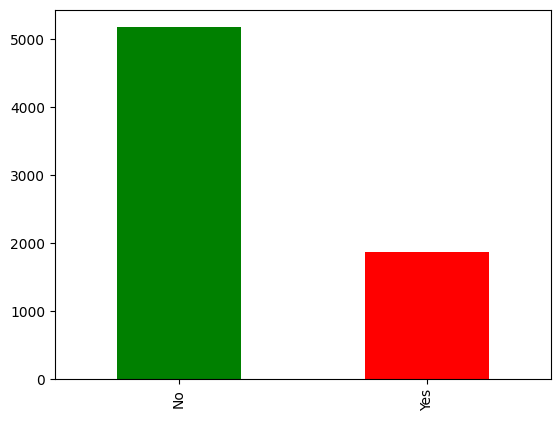

In [4]:
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])


In [5]:
# Key Finding:

# 73.5% customers stayed (No churn)

# 26.5% customers left (Churned)

# Imbalanced dataset! (We'll fix this later)

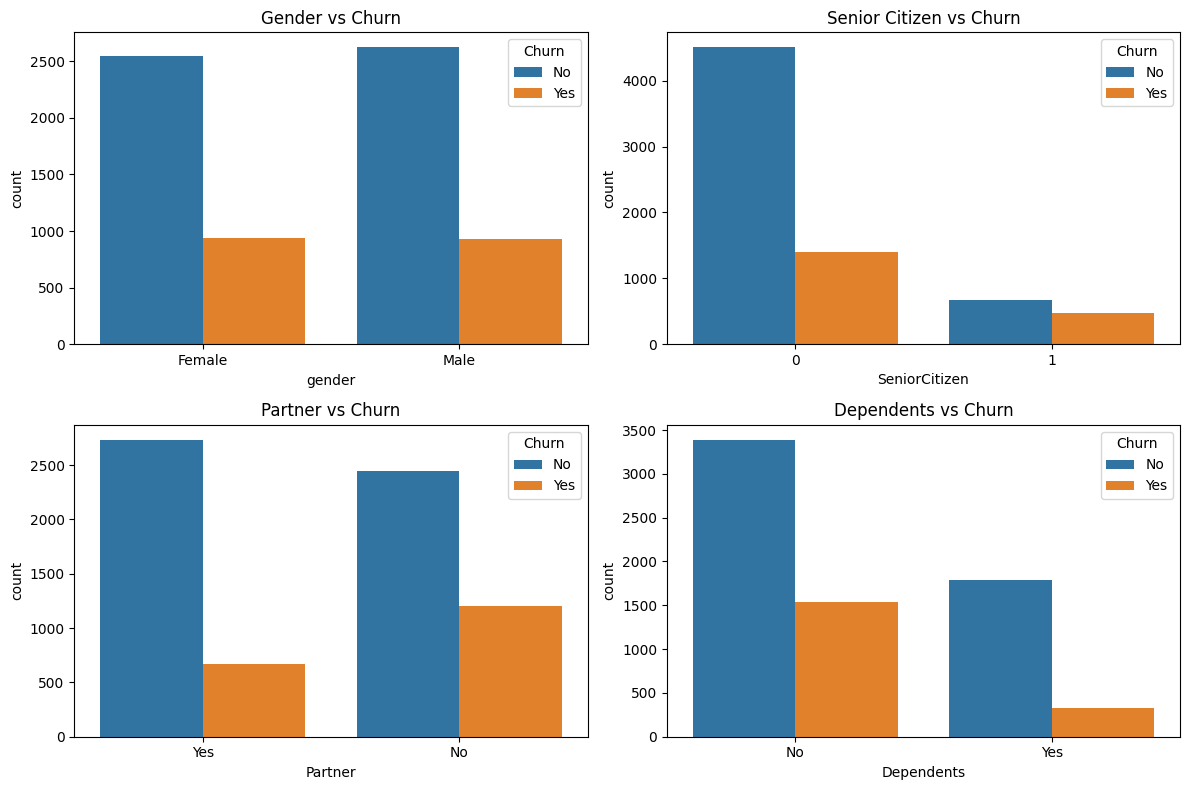

In [6]:
# Plot demographic features vs Churn
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gender vs Churn
sns.countplot(data=df, x='gender', hue='Churn', ax=axes[0,0])
axes[0,0].set_title('Gender vs Churn')

# Senior Citizen vs Churn
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0,1])
axes[0,1].set_title('Senior Citizen vs Churn')

# Partner vs Churn
sns.countplot(data=df, x='Partner', hue='Churn', ax=axes[1,0])
axes[1,0].set_title('Partner vs Churn')

# Dependents vs Churn
sns.countplot(data=df, x='Dependents', hue='Churn', ax=axes[1,1])
axes[1,1].set_title('Dependents vs Churn')

plt.tight_layout()
plt.show()


In [7]:
# Insights:

# Gender: Almost equal churn rate for male/female

# Senior Citizens: Higher churn rate

# No Partner: Higher churn rate

# No Dependents: Higher churn rate

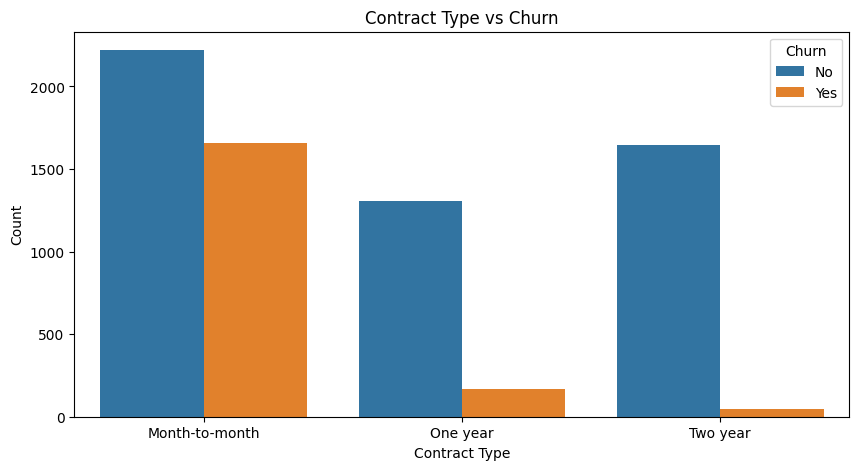

Churn rate by contract type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [8]:
# Contract type is VERY important
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Calculate churn rate by contract
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print("Churn rate by contract type:")
print(contract_churn)


In [9]:
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

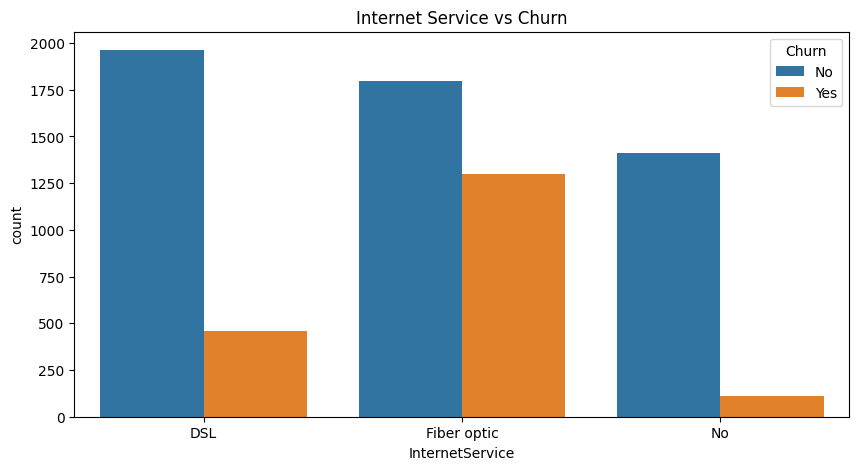

Churn rate by internet service:
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Internet Service vs Churn')
plt.show()

# Churn rate by internet service
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print("Churn rate by internet service:")
print(internet_churn)


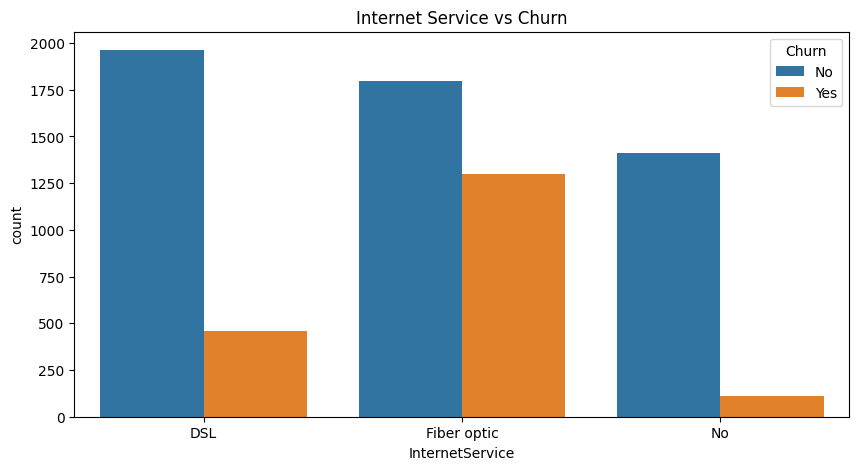

Churn rate by internet service:
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64


In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Internet Service vs Churn')
plt.show()

# Churn rate by internet service
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print("Churn rate by internet service:")
print(internet_churn)


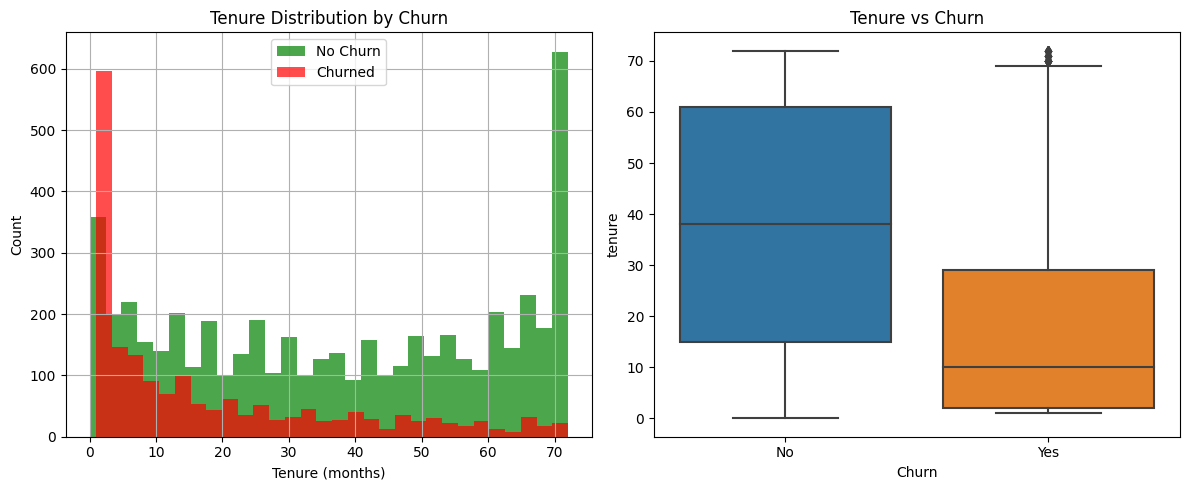

In [12]:
# Tenure (how long customer has been with company)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

# simple histograms can be plot for  the understanding

df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.7, label='No Churn', color='green')

df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7, label='Churned', color='red')

plt.xlabel('Tenure (months)')
plt.ylabel('Count')

plt.title('Tenure Distribution by Churn')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')

plt.tight_layout()
plt.show()


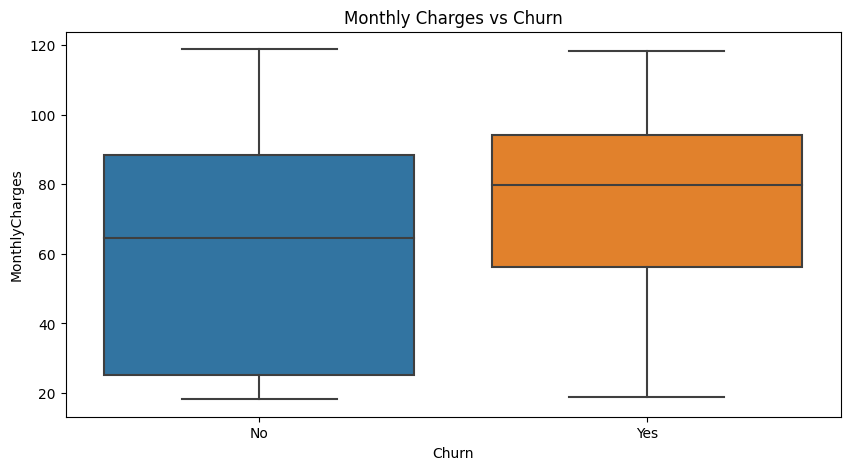

Average Monthly Charges:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [13]:
# Monthly Charges
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

# Average monthly charges by churn
print("Average Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean())


In [14]:
# Churned customers pay MORE per month ($74.44 vs $61.27)

# High prices drive customers away!

In [16]:
# Now handling the missing values 

In [20]:
# Convert TotalCharges to numeric (it's stored as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [22]:
 df['TotalCharges'].isnull().sum() # this are the missing values 

11

In [23]:
# Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)


In [26]:
# Convert Churn to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [31]:
print(df['Churn'].value_counts())


0    5174
1    1869
Name: Churn, dtype: int64


In [34]:
# identify categoricals 
categorical_cols =df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
# deciding the columns and features to turn binary or not ot convert one hot encoding 

In [35]:
binary_cols=['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [38]:
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [39]:
# Handle other categorical columns
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})


In [40]:
# One-hot encoding for multi-category columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod', 
                                  'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport', 'StreamingTV', 
                                  'StreamingMovies'], 
                     drop_first=True)

In [41]:
print("\nDataset shape after encoding:", df.shape)
print("\nAll columns are now numeric:")
print(df.dtypes.unique())


Dataset shape after encoding: (7043, 31)

All columns are now numeric:
[dtype('int64') dtype('float64') dtype('uint8')]


In [ ]:
# Feature Scaling  or converleting tenure,montlycharges,totalcharges to same sac

In [43]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns to scale
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create scaler
scaler = StandardScaler()


In [ ]:
# i think  it will  use (each_value -mean/std)

In [45]:
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [49]:
print("Features after scaling:")
print(df[numeric_cols].describe())

Features after scaling:
             tenure  MonthlyCharges  TotalCharges
count  7.043000e+03    7.043000e+03  7.032000e+03
mean  -2.421273e-17   -6.406285e-17  8.159318e-17
std    1.000071e+00    1.000071e+00  1.000071e+00
min   -1.318165e+00   -1.545860e+00 -9.990692e-01
25%   -9.516817e-01   -9.725399e-01 -8.302488e-01
50%   -1.372744e-01    1.857327e-01 -3.908151e-01
75%    9.214551e-01    8.338335e-01  6.668271e-01
max    1.613701e+00    1.794352e+00  2.824261e+00


In [51]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
0    5174
1    1869
Name: Churn, dtype: int64


In [56]:
from sklearn.model_selection import train_test_split

# Split data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining set churn distribution:")
print(y_train.value_counts())

Training set size: (4930, 30)
Test set size: (2113, 30)

Training set churn distribution:
0    3622
1    1308
Name: Churn, dtype: int64


In [58]:
# filling the nan values

In [59]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # Or use 'median' if distribution is skewed
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [60]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
0    3622
1    1308
Name: Churn, dtype: int64

After SMOTE:
0    3622
1    3622
Name: Churn, dtype: int64


In [61]:
# Model Building 

In [72]:
# now applying the logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_balanced, y_train_balanced)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")


Logistic Regression Results:
Accuracy: 0.7473
Precision: 0.5155
Recall: 0.8004
F1-Score: 0.6271
ROC-AUC: 0.8438


In [64]:
# Accuracy: Overall correct predictions (out of 100)

# Precision: Of customers we predicted will churn, how many actually churned?

# Recall: Of customers who actually churned, how many did we catch?

# F1-Score: Balance between precision and recall

# ROC-AUC: Model's ability to distinguish between classes (higher = better)

In [73]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\nRandom Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")



Random Forest Results:
Accuracy: 0.7814
Precision: 0.5902
Recall: 0.5775
F1-Score: 0.5838
ROC-AUC: 0.8158


In [74]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_balanced, y_train_balanced)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\nXGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")



XGBoost Results:
Accuracy: 0.7752
Precision: 0.5754
Recall: 0.5847
F1-Score: 0.5800
ROC-AUC: 0.8117



Model Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.747279   0.515499  0.800357  0.627095  0.843768
1        Random Forest  0.781354   0.590164  0.577540  0.583784  0.815800
2              XGBoost  0.775201   0.575439  0.584670  0.580018  0.811722


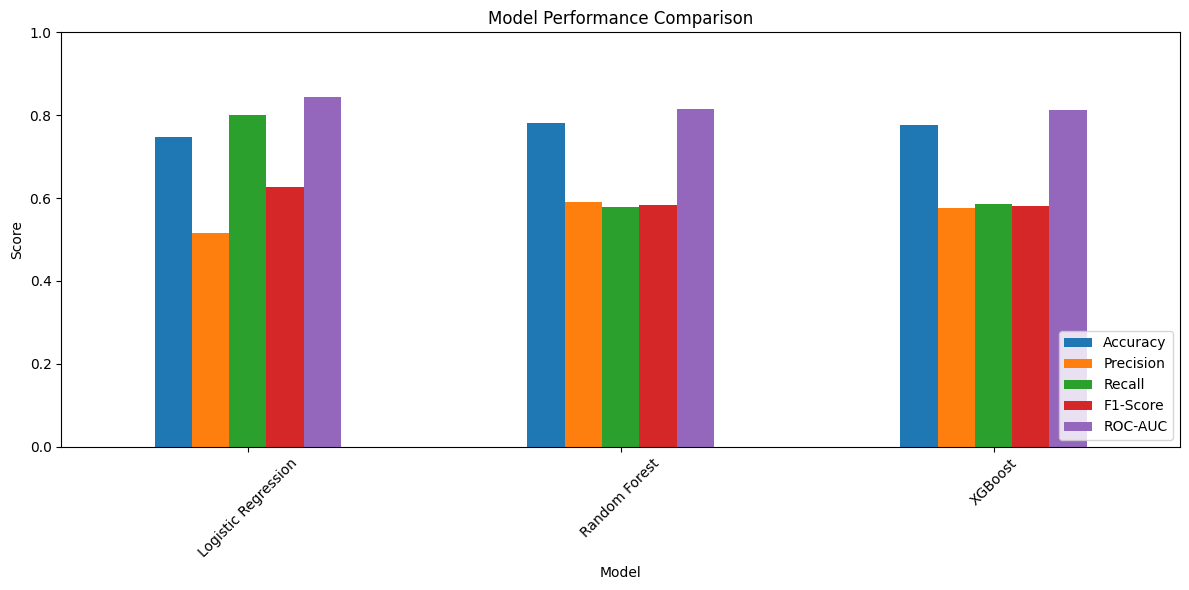

In [75]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
})

print("\nModel Comparison:")
print(results)

# Visualize comparison
results.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# Choose Best Model:

# Pick model with highest F1-Score or ROC-AUC

# For business: Recall is important (catch churning customers)

# Usually Random Forest or XGBoost performs best

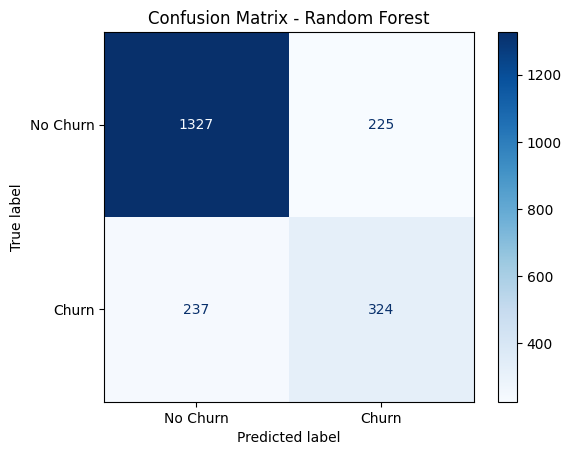


Confusion Matrix:
[[1327  225]
 [ 237  324]]

True Negatives (Correct No Churn): 1327
False Positives (Wrong Churn prediction): 225
False Negatives (Missed Churns): 237
True Positives (Correct Churn): 324


In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for best model (e.g., Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)

# Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("\nConfusion Matrix:")
print(cm)
print("\nTrue Negatives (Correct No Churn):", cm[0,0])
print("False Positives (Wrong Churn prediction):", cm[0,1])
print("False Negatives (Missed Churns):", cm[1,0])
print("True Positives (Correct Churn):", cm[1,1])


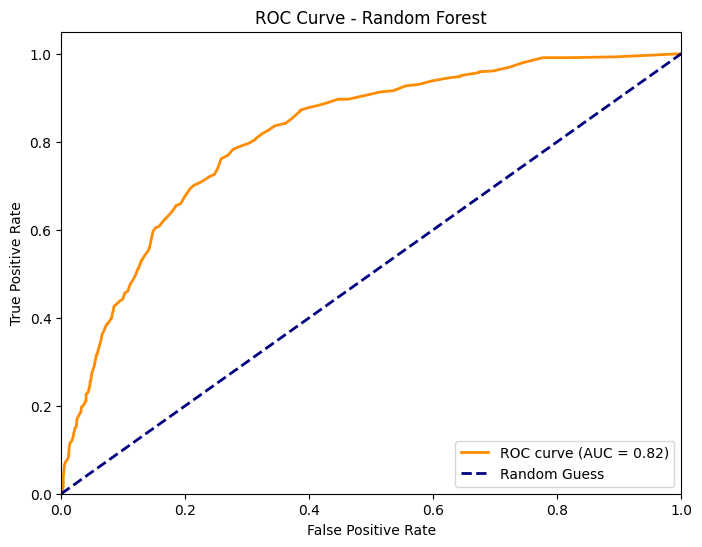

In [77]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()


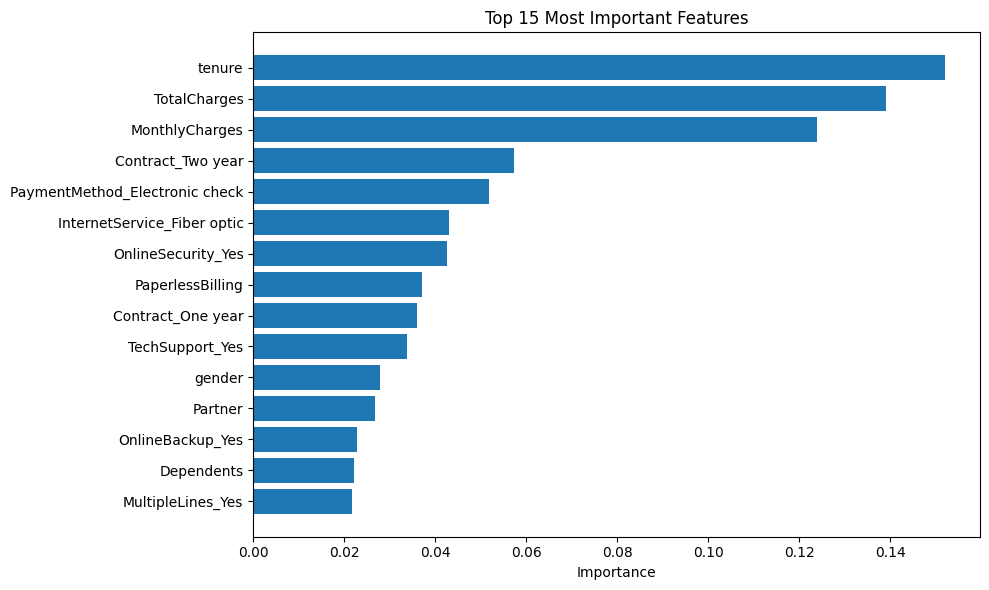


Top 10 Important Features:
                           Feature  Importance
4                           tenure    0.152070
8                     TotalCharges    0.139095
7                   MonthlyCharges    0.123758
12               Contract_Two year    0.057258
14  PaymentMethod_Electronic check    0.051816
9      InternetService_Fiber optic    0.043042
19              OnlineSecurity_Yes    0.042579
6                 PaperlessBilling    0.037068
11               Contract_One year    0.035961
25                 TechSupport_Yes    0.033714


In [78]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(feature_importance.head(10))


In [81]:
import os
import joblib

os.makedirs('models', exist_ok=True)  # <-- MUST run this first

joblib.dump(rf_model, 'models/churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'models/feature_names.pkl')

print("Model saved successfully!")



Model saved successfully!
